# BRAIN TUMOR CLASSIFCATION

In [ ]:
# Install dependencies (if needed)
!pip install -q tensorflow matplotlib scikit-learn

In [ ]:
# Imports
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import matplotlib.pyplot as plt
import numpy as np
import os
from sklearn.metrics import classification_report, confusion_matrix
from tensorflow.keras.applications.vgg16 import preprocess_input
from tensorflow.keras.applications.resnet50 import preprocess_input

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# Update this path
data_dir = "/content/drive/MyDrive/brain_tumor_dataset"

In [ ]:
img_size = (224, 224)
batch_size = 32

train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=img_size,
    batch_size=batch_size
)

val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=img_size,
    batch_size=batch_size
)

class_names = train_ds.class_names
print("Classes:", class_names)

Found 1800 files belonging to 4 classes.
Using 1440 files for training.
Found 1800 files belonging to 4 classes.
Using 360 files for validation.
Classes: ['glioma', 'meningioma', 'notumor', 'pituitary']


In [ ]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)

In [ ]:
data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1)
])

In [ ]:
cnn_model = keras.Sequential([
    data_augmentation,
    layers.Rescaling(1./255),

    layers.Conv2D(32, (3,3), activation='relu'),
    layers.MaxPooling2D(),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D(),

    layers.Conv2D(128, (3,3), activation='relu'),
    layers.MaxPooling2D(),

    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),

    layers.Dense(4, activation='softmax')  # 4 classes
])

In [ ]:
cnn_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

history_cnn = cnn_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=30,
    callbacks=[early_stop]
)

Epoch 1/30
45/45 ━━━━━━━━━━━━━━━━━━━━ 25s 98ms/step - accuracy: 0.4076 - loss: 1.3108 - val_accuracy: 0.5944 - val_loss: 0.9769
Epoch 2/30
45/45 ━━━━━━━━━━━━━━━━━━━━ 3s 66ms/step - accuracy: 0.5660 - loss: 1.0095 - val_accuracy: 0.6083 - val_loss: 0.9475
Epoch 3/30
45/45 ━━━━━━━━━━━━━━━━━━━━ 4s 91ms/step - accuracy: 0.6201 - loss: 0.8964 - val_accuracy: 0.6722 - val_loss: 0.8514
Epoch 4/30
45/45 ━━━━━━━━━━━━━━━━━━━━ 4s 84ms/step - accuracy: 0.6681 - loss: 0.8356 - val_accuracy: 0.6972 - val_loss: 0.7128
Epoch 5/30
45/45 ━━━━━━━━━━━━━━━━━━━━ 3s 64ms/step - accuracy: 0.6653 - loss: 0.8031 - val_accuracy: 0.6639 - val_loss: 0.7468
Epoch 6/30
45/45 ━━━━━━━━━━━━━━━━━━━━ 3s 64ms/step - accuracy: 0.6944 - loss: 0.7679 - val_accuracy: 0.7417 - val_loss: 0.6614
Epoch 7/30
45/45 ━━━━━━━━━━━━━━━━━━━━ 3s 61ms/step - accuracy: 0.7250 - loss: 0.7097 - val_accuracy: 0.6972 - val_loss: 0.6330
Epoch 8/30
45/45 ━━━━━━━━━━━━━━━━━━━━ 3s 63ms/step - accuracy: 0.7160 - loss: 0.6681 - val_accuracy: 0.7444 - 

In [ ]:
base_model = tf.keras.applications.VGG16(
    weights='imagenet',
    include_top=False,
    input_shape=(224,224,3)
)

base_model.trainable = False

In [ ]:
vgg_model = keras.Sequential([
    data_augmentation,
    layers.Lambda(preprocess_input),

    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(4, activation='softmax')
])

In [ ]:
vgg_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history_vgg = vgg_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=30,
    callbacks=[early_stop]
)

Epoch 1/30
45/45 ━━━━━━━━━━━━━━━━━━━━ 13s 225ms/step - accuracy: 0.5326 - loss: 2.0893 - val_accuracy: 0.7167 - val_loss: 0.6870
Epoch 2/30
45/45 ━━━━━━━━━━━━━━━━━━━━ 10s 219ms/step - accuracy: 0.6736 - loss: 0.8253 - val_accuracy: 0.7889 - val_loss: 0.5833
Epoch 3/30
45/45 ━━━━━━━━━━━━━━━━━━━━ 9s 211ms/step - accuracy: 0.7181 - loss: 0.7164 - val_accuracy: 0.7972 - val_loss: 0.5458
Epoch 4/30
45/45 ━━━━━━━━━━━━━━━━━━━━ 9s 203ms/step - accuracy: 0.7604 - loss: 0.6179 - val_accuracy: 0.8083 - val_loss: 0.4964
Epoch 5/30
45/45 ━━━━━━━━━━━━━━━━━━━━ 9s 194ms/step - accuracy: 0.7757 - loss: 0.5700 - val_accuracy: 0.7861 - val_loss: 0.5281


In [ ]:
base_model = tf.keras.applications.ResNet50(
    weights='imagenet',
    include_top=False,
    input_shape=(224,224,3)
)

base_model.trainable = False

In [ ]:
resnet_model = keras.Sequential([
    data_augmentation,
    layers.Lambda(preprocess_input),

    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(4, activation='softmax')
])

In [ ]:
resnet_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history_resnet = resnet_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=30,
    callbacks=[early_stop]
)

Epoch 1/30
45/45 ━━━━━━━━━━━━━━━━━━━━ 19s 240ms/step - accuracy: 0.6139 - loss: 1.0139 - val_accuracy: 0.8278 - val_loss: 0.5088
Epoch 2/30
45/45 ━━━━━━━━━━━━━━━━━━━━ 8s 175ms/step - accuracy: 0.7556 - loss: 0.5944 - val_accuracy: 0.8583 - val_loss: 0.4345
Epoch 3/30
45/45 ━━━━━━━━━━━━━━━━━━━━ 8s 189ms/step - accuracy: 0.7875 - loss: 0.5365 - val_accuracy: 0.8528 - val_loss: 0.4176
Epoch 4/30
45/45 ━━━━━━━━━━━━━━━━━━━━ 8s 188ms/step - accuracy: 0.7979 - loss: 0.4818 - val_accuracy: 0.8861 - val_loss: 0.3931
Epoch 5/30
45/45 ━━━━━━━━━━━━━━━━━━━━ 9s 194ms/step - accuracy: 0.8236 - loss: 0.4520 - val_accuracy: 0.8528 - val_loss: 0.3977
Epoch 6/30
45/45 ━━━━━━━━━━━━━━━━━━━━ 9s 193ms/step - accuracy: 0.8299 - loss: 0.4301 - val_accuracy: 0.8639 - val_loss: 0.3712
Epoch 7/30
45/45 ━━━━━━━━━━━━━━━━━━━━ 8s 182ms/step - accuracy: 0.8319 - loss: 0.4062 - val_accuracy: 0.8667 - val_loss: 0.3582
Epoch 8/30
45/45 ━━━━━━━━━━━━━━━━━━━━ 8s 179ms/step - accuracy: 0.8556 - loss: 0.3801 - val_accuracy: 0

In [ ]:
# Unfreeze ResNet for fine-tuning
base_model.trainable = True

# Freeze most layers, train only top layers
for layer in base_model.layers[:-30]:
    layer.trainable = False

In [ ]:
resnet_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)
history_fine = resnet_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=15,
    callbacks=[early_stop]
)

Epoch 1/15
45/45 ━━━━━━━━━━━━━━━━━━━━ 31s 315ms/step - accuracy: 0.8062 - loss: 0.4740 - val_accuracy: 0.8639 - val_loss: 0.3656
Epoch 2/15
45/45 ━━━━━━━━━━━━━━━━━━━━ 12s 279ms/step - accuracy: 0.8861 - loss: 0.3177 - val_accuracy: 0.8583 - val_loss: 0.3482
Epoch 3/15
45/45 ━━━━━━━━━━━━━━━━━━━━ 10s 233ms/step - accuracy: 0.8938 - loss: 0.2859 - val_accuracy: 0.8750 - val_loss: 0.3260
Epoch 4/15
45/45 ━━━━━━━━━━━━━━━━━━━━ 10s 225ms/step - accuracy: 0.9111 - loss: 0.2673 - val_accuracy: 0.8917 - val_loss: 0.2996
Epoch 5/15
45/45 ━━━━━━━━━━━━━━━━━━━━ 10s 221ms/step - accuracy: 0.9278 - loss: 0.2208 - val_accuracy: 0.8833 - val_loss: 0.2982


In [ ]:
def evaluate_model(model, val_ds):
    y_true = []
    y_pred = []

    for images, labels in val_ds:
        preds = model.predict(images)
        y_true.extend(labels.numpy())
        y_pred.extend(np.argmax(preds, axis=1))

    print(classification_report(y_true, y_pred))
    print(confusion_matrix(y_true, y_pred))

In [ ]:
print("CNN Results:")
evaluate_model(cnn_model, val_ds)

print("VGG16 Results:")
evaluate_model(vgg_model, val_ds)

print("ResNet50 Results:")
evaluate_model(resnet_model, val_ds)

CNN Results:
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 169ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
              precision    recall  f1-score   support

           0       0.71      0.72      0.71        85
           1       0.72      0.63      0.67        99
           2       0.91      0.96      0.93        90
           3       0.89      0.97      0.93        86

    accuracy                           0.81       360
   macro avg       0.81      0.82      0.81       360
weighted avg       0.81      0.81      0.81       360

[[61 18  5  1]
 [24 62  4  9]
 [ 1  3 86  0]
 [ 0  3  0 83]]
VGG16 Results:
1/1 ━━━━━━━━━━━━━━━

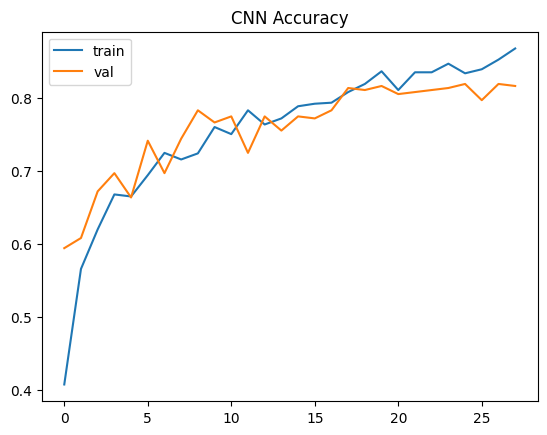

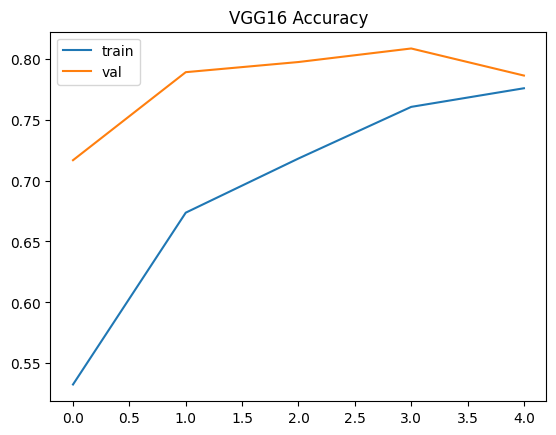

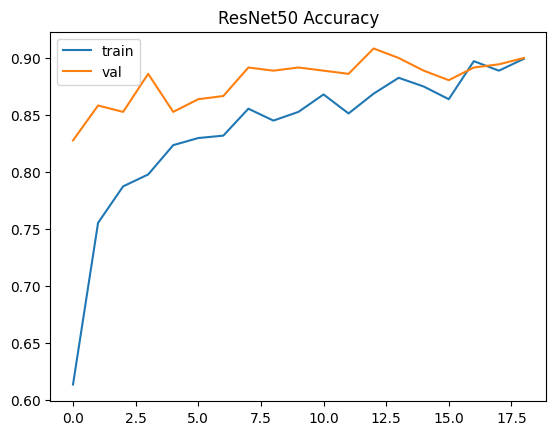

In [ ]:
def plot_history(history, title):
    plt.plot(history.history['accuracy'], label='train')
    plt.plot(history.history['val_accuracy'], label='val')
    plt.title(title)
    plt.legend()
    plt.show()

plot_history(history_cnn, "CNN Accuracy")
plot_history(history_vgg, "VGG16 Accuracy")
plot_history(history_resnet, "ResNet50 Accuracy")

In [ ]:
cnn_model.save("cnn_model.h5")
vgg_model.save("vgg_model.h5")
resnet_model.save("resnet_model.h5")

In [ ]:
from google.colab import files
from tensorflow.keras.preprocessing import image
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
uploaded = files.upload()

Saving Te-gl_77.jpg to Te-gl_77.jpg


In [ ]:
def predict_image(model, img_path):
    from tensorflow.keras.applications.resnet50 import preprocess_input

    img = image.load_img(img_path, target_size=(224,224))
    img_array = image.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0)
    img_array = preprocess_input(img_array)

    prediction = model.predict(img_array)
    predicted_class = class_names[np.argmax(prediction)]
    confidence = np.max(prediction)

    plt.imshow(img)
    plt.title(f"{predicted_class} ({confidence*100:.2f}%)")
    plt.axis("off")
    plt.show()

    print("Prediction probabilities:", prediction)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step


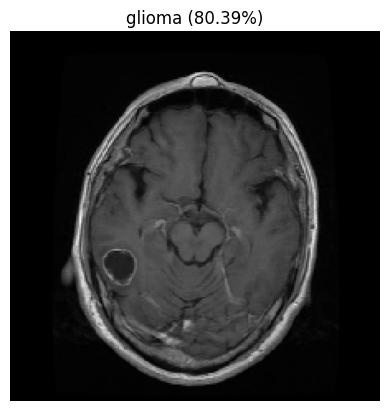

Prediction probabilities: [[0.80389166 0.04148955 0.07459629 0.08002247]]


In [ ]:
for file_name in uploaded.keys():
    predict_image(resnet_model, file_name)